In [1]:
import os
os.chdir("../")
from src.adecuacion import corrector, ImagenHyper
from src.spacial_bin import binning
from src.labeling import identificar_muestras1, enseñar_muestras,y_prop_label_generation, y_prop_label_generation, combinar_labels, espectros_muestras
from src.rgb import img_rgb, imagen_prediccion, imagen_labelling
import matplotlib.pyplot as plt
import numpy as np
ruta1="""E:/TFM IMAGENES/IMAGENES/"""
dia='30ene2026/'
nombre_muestra='30ene2026_0003_sonabia'
ruta2='/capture/'
white='WHITEREF_'
dark='DARKREF_'
extension='.hdr'

"D:\TFM IMAGENES\IMAGENES\30ene2026\30ene2026_0001_arenas\capture\WHITEREF_30ene2026_0001_arenas.hdr"
ruta_imagen=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/{nombre_muestra}{extension}"
ruta_blanco=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/WHITEREF_{nombre_muestra}{extension}"
ruta_negro=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/DARKREF_{nombre_muestra}{extension}"
imagen_sonabia =corrector(ruta_imagen=ruta_imagen,ruta_blanco=ruta_blanco,ruta_negro=ruta_negro)

<>:17: SyntaxWarning: invalid escape sequence '\T'
<>:17: SyntaxWarning: invalid escape sequence '\T'
C:\Users\unaif\AppData\Local\Temp\ipykernel_18356\2418996281.py:17: SyntaxWarning: invalid escape sequence '\T'
  "D:\TFM IMAGENES\IMAGENES\30ene2026\30ene2026_0001_arenas\capture\WHITEREF_30ene2026_0001_arenas.hdr"
c:\Users\unaif\anaconda3\envs\TFM\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


In [2]:
imagen_sonabia=ImagenHyper(imagen_sonabia[0],imagen_sonabia[1] )

In [3]:
sonabia_binned=binning(imagen_sonabia,2)

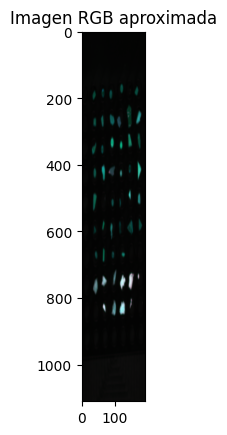

In [4]:
img_rgb(sonabia_binned.img)

In [5]:
from sklearn.cluster import KMeans

from src.adecuacion import img2matrix, matrix2img, ImagenHyper, replace_from_coords

n_clusters = 5
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)
h, w, b = sonabia_binned.shape
labels = kmeans.fit_predict(sonabia_binned.spectra)

cluster_map=matrix2img(labels,h=h, w=w, b=1)

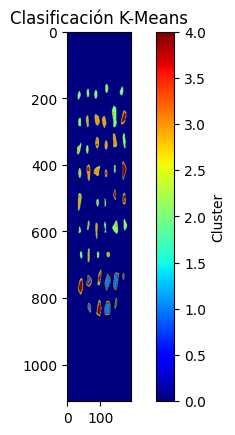

In [6]:

plt.imshow(cluster_map, cmap="jet")
plt.colorbar(label="Cluster")
plt.title("Clasificación K-Means")
plt.show()

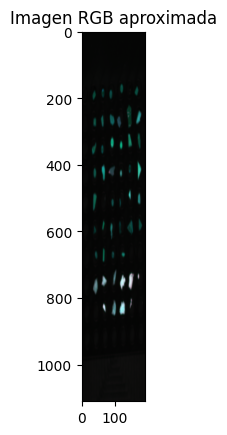

In [7]:
mask = np.argwhere(cluster_map == 0)[:,0:2]
img_rgb(replace_from_coords(sonabia_binned.img, cluster_map,0))

In [8]:
mask=replace_from_coords(sonabia_binned.img, mask, 0).astype(bool)[:,:,0]
mask
sonabia_binned.add_mask(mask=mask)
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(1111, 192))

In [9]:
sonabia_binned.add_mask(mask=mask)

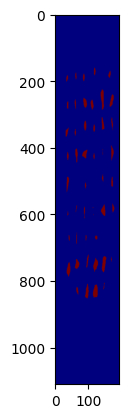

In [10]:
from skimage.morphology import erosion, disk
import matplotlib.pyplot as plt
mask_eroded = erosion(sonabia_binned.mask, disk(2) )

plt.Figure(figsize=(15,15))
plt.imshow(mask_eroded, cmap="jet")

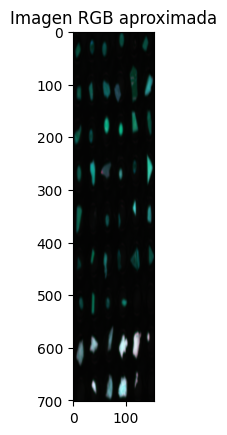

In [11]:
sonabia_binned.add_mask(mask_eroded)
sonabia_binned_sliced=sonabia_binned.slicer("auto")
img_rgb(sonabia_binned_sliced.img)

In [12]:
n_plasticos, props=identificar_muestras1(sonabia_binned_sliced)

Plásticos detectados: 49


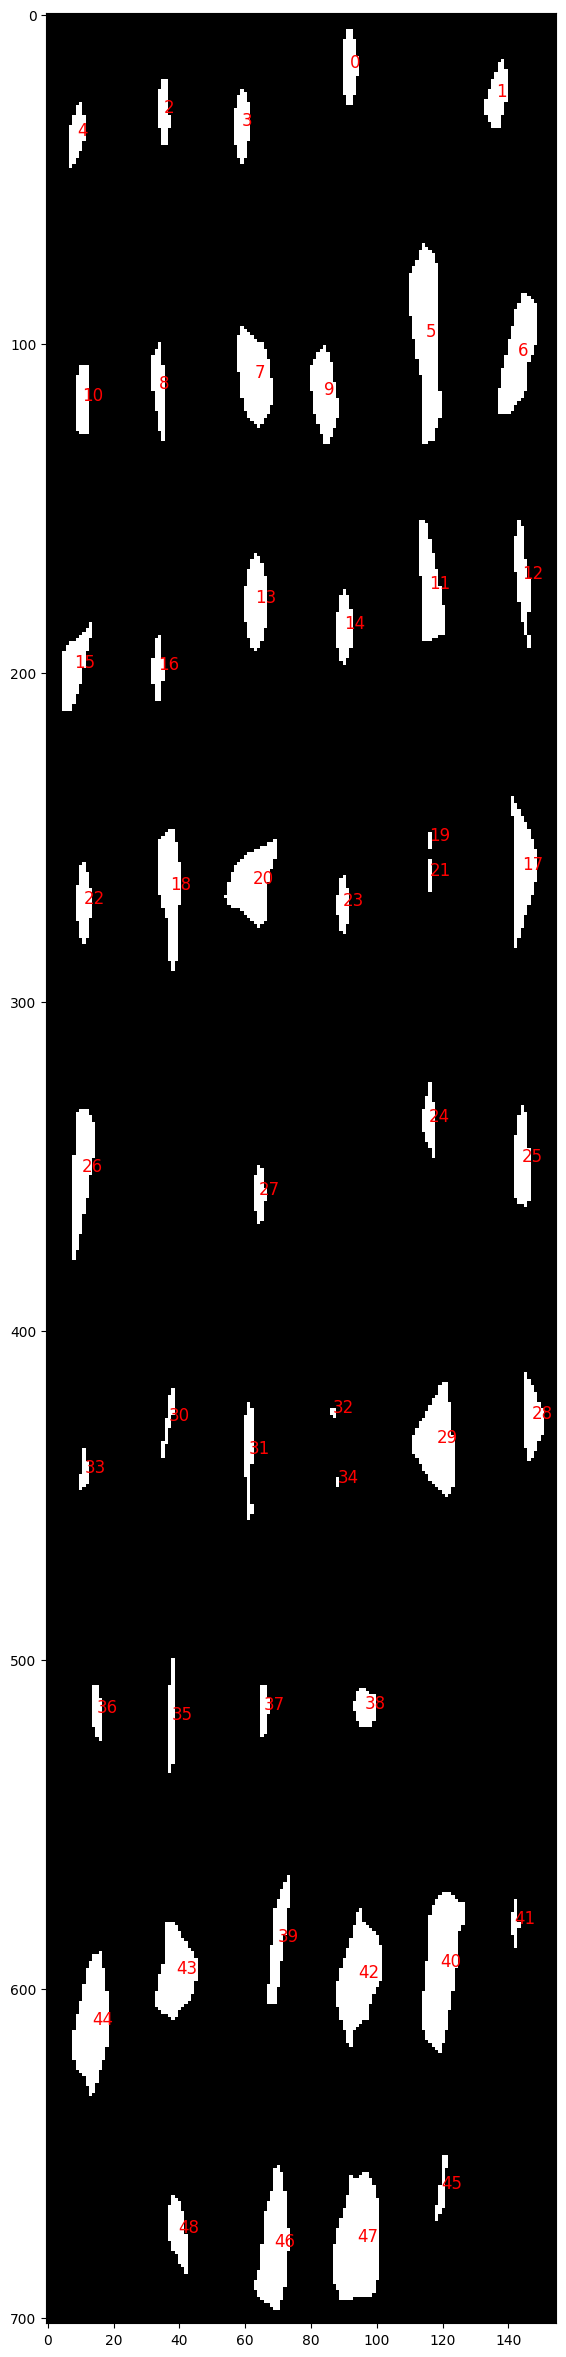

In [13]:
enseñar_muestras(sonabia_binned_sliced.mask, props=props)

In [14]:
espectros_muestras(props=props, img=sonabia_binned_sliced, preprocesado="SNV")

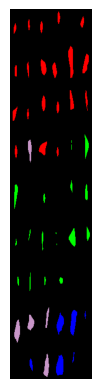

In [15]:
y_prop_label=y_prop_label_generation(n_plasticos)
y_prop_label[0:23]=1
y_prop_label[23:39]=2
y_prop_label[39:49]=3




y_prop_label[23]=1
y_prop_label[17]=2
y_prop_label[19]=2
y_prop_label[21]=2
y_prop_label[18]=0
y_prop_label[44]=0
y_prop_label[43]=0
y_prop_label[39]=0

y_prop_label[46]=0



imagen_labelling(y_prop=y_prop_label, props=props, shape=sonabia_binned_sliced.shape
                 )

In [16]:
---

SyntaxError: invalid syntax (1947214667.py, line 1)

In [17]:
os.getcwd()

'c:\\Users\\unaif\\TFM PYTHON\\Repositorio\\TFM'

In [18]:
combinar_labels(sonabia_binned_sliced,y_prop_label, props)

In [ ]:
---

In [19]:
import pickle
with open("DATA/sonabia_binned_sliced.pkl", "wb") as f:
    pickle.dump(sonabia_binned_sliced, f)

True